# Paramétrage de l'environnement de travail et import des packages

In [1]:
import sys
from pathlib import Path

In [2]:
ROOT = Path.cwd().parents[0]

MODEL_DATA = ROOT / "04_model"
PROCESSED_DATA = ROOT / "01_data" / "02_processed"
JOBLIB_DATA = ROOT / "01_data" / "03_joblib"

%load_ext autoreload
%autoreload 2
sys.path.append(str(ROOT / "03_fonctions"))

In [4]:
import shap
from fonctions_perso.machine_learning import waterfall_plot
import joblib
from sklearn import set_config

# Interpretation - SHAP

**Import des objets nécéssaires**

In [14]:
# full_test_sample
full_test_sample = joblib.load(JOBLIB_DATA / "full_test_sample.joblib")

# x_test_sample
x_test_sample = joblib.load(JOBLIB_DATA / "x_test_sample.joblib")

# x_test_proc
x_test_proc = joblib.load(JOBLIB_DATA / "x_test_processed.joblib")

# SHAP Values
shap_values = joblib.load(JOBLIB_DATA / "shap_values_modele.joblib")

**Feature Importance**

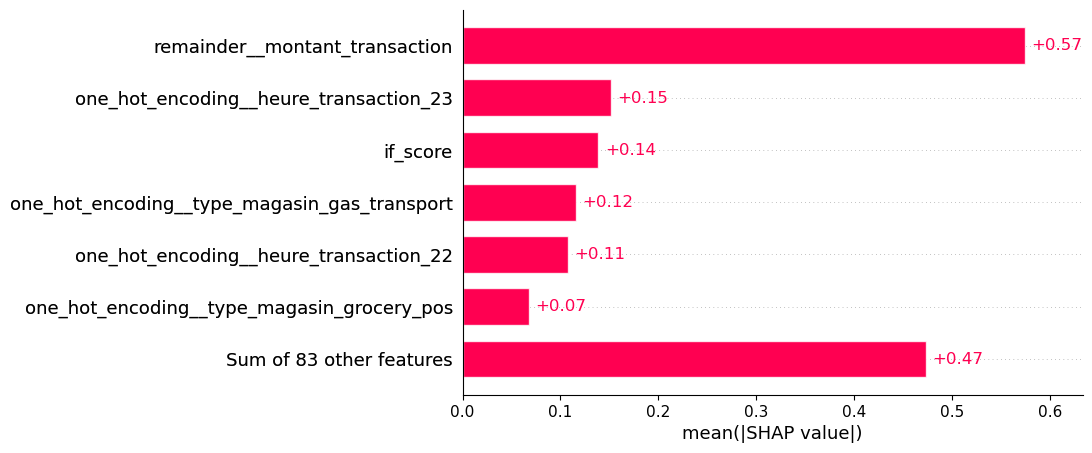

In [12]:
shap.plots.bar(shap_values, max_display=7)

**Beeswarm Plot**

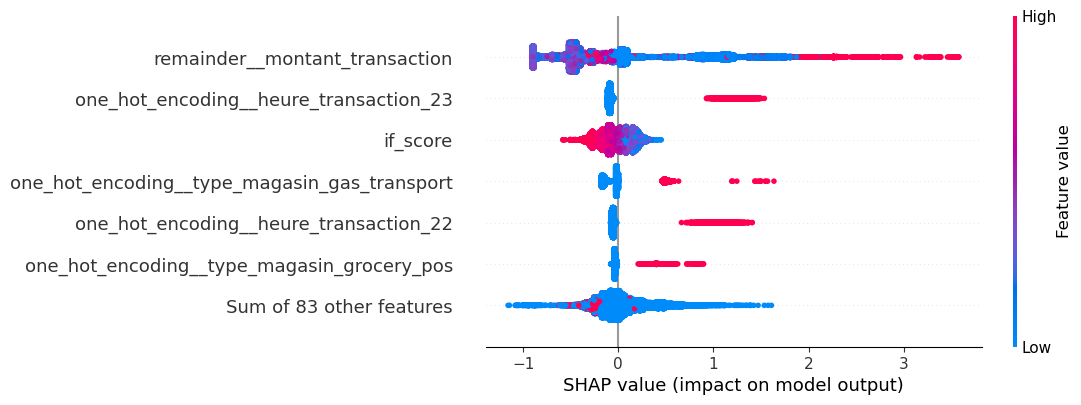

In [13]:
shap.plots.beeswarm(shap_values, max_display=7)

**Waterfall Plot**

In [18]:
full_test_sample.sample(6)

,type_magasin,montant_transaction,etat_client,heure_transaction,age_client,target
3985,entertainment,73.93,NY,12,39,0
33716,gas_transport,44.08,ME,9,50,0
17499,gas_transport,56.62,AL,5,49,0
11251,shopping_net,6.11,CO,18,45,0
9988,gas_transport,68.46,IA,1,67,0
16420,kids_pets,39.77,KY,20,23,0


Quelles explications pour une transaction légitime ?

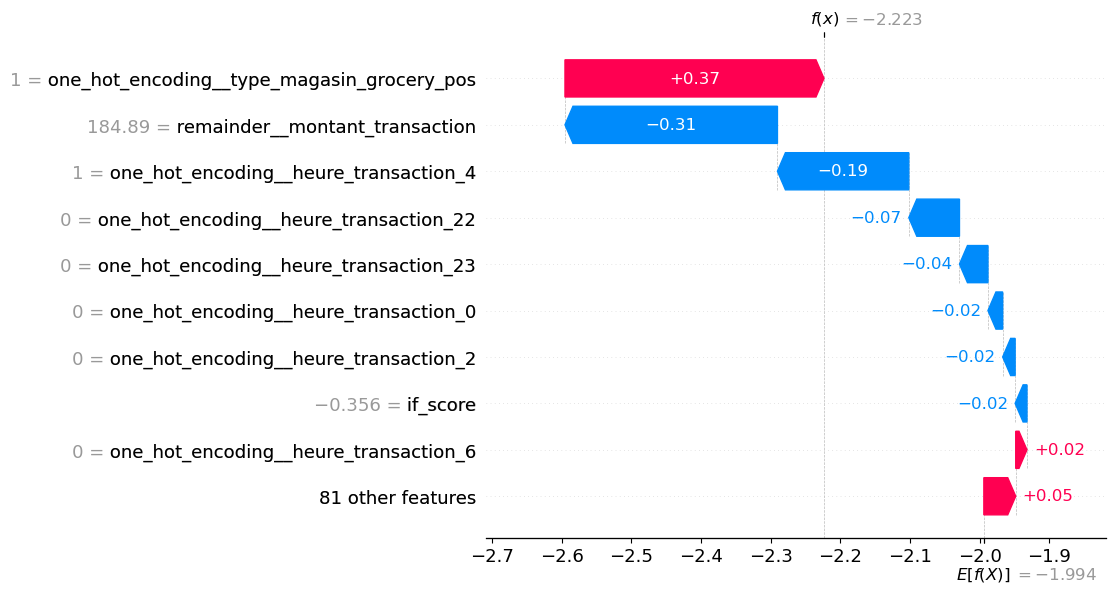

In [70]:
waterfall_plot(
    shap_values,
    x_test_proc,
    255,
    max_display=10
)

Quelles explications pour une transaction frauduleuse ?

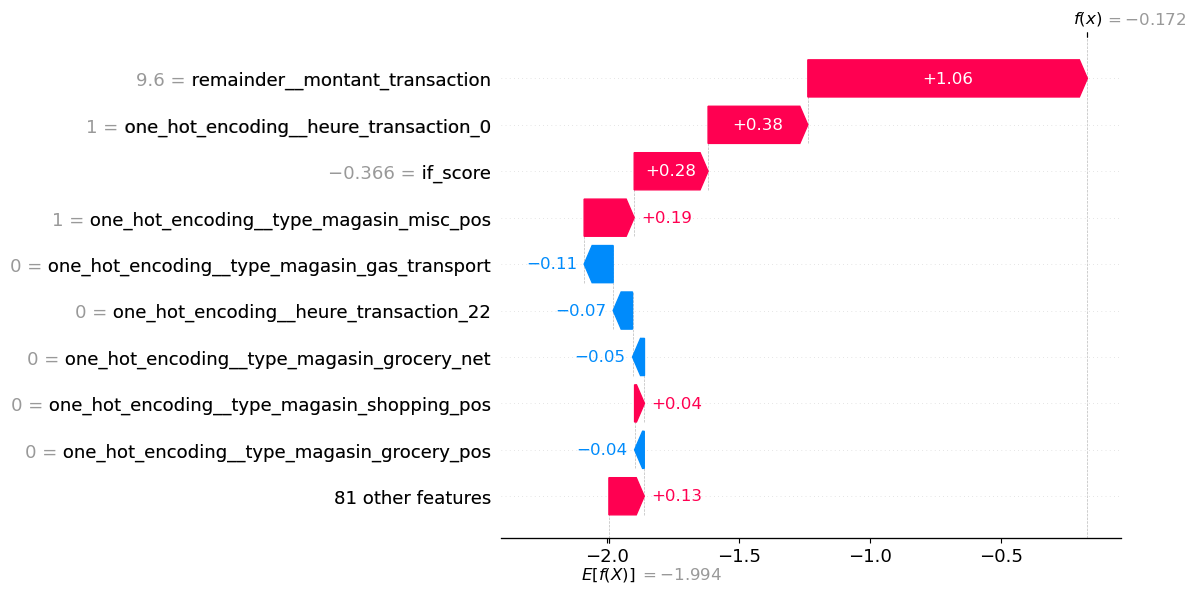

In [69]:
waterfall_plot(
    shap_values,
    x_test_proc,
    35,
    max_display=10
)

**Interactions dans les données**

Relation montant_transaction | if_score | probabilité de transaction frauduleuse

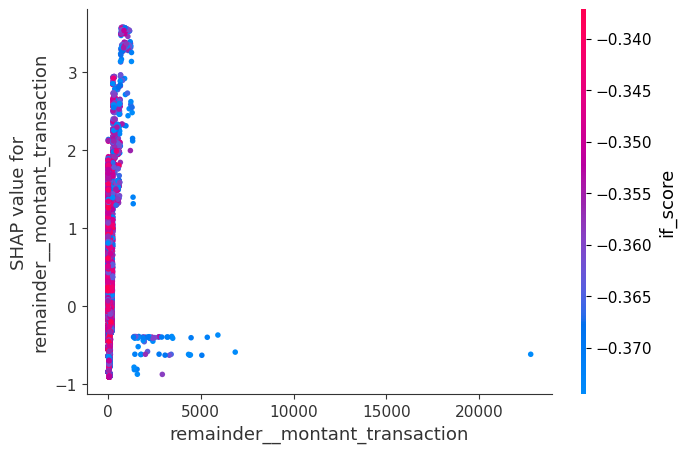

In [20]:
shap.dependence_plot(
    "remainder__montant_transaction",      
    shap_values.values,
    x_test_proc,
    interaction_index="if_score"
)

# Note explicative du Notebook 

Ce notebook analyse le comportement du modèle de détection de fraude à l’aide de SHAP.  
L’analyse est menée à trois niveaux : importance globale des variables, effets moyens (beeswarm) et explications locales (waterfall), complétées par l’étude des interactions.

---

## Importance des variables

La variable la plus influente est le **montant de la transaction** (`montant_transaction`).  
Elle présente l’impact moyen le plus important sur le score de fraude.

Viennent ensuite plusieurs variables de contexte :

- l’**heure de la transaction** (notamment 22h et 23h),
- le **score d’anomalie** `if_score` issu de l’Isolation Forest,
- le **type de magasin** (`gas_transport`, `grocery_pos`).

Ces variables constituent les principaux signaux utilisés par le modèle pour différencier transactions légitimes et frauduleuses.

---

## Effets moyens (Beeswarm)

### Montant de la transaction

Les montants modérés ont tendance à être associés à des transactions légitimes.  
À l’inverse, les montants très faibles ou très élevés augmentent la probabilité de fraude, car ils correspondent à des comportements plus atypiques.

### Heure de transaction

Certaines plages horaires, notamment en soirée et durant la nuit (22h, 23h), sont associées à une augmentation du risque.

### Score d’anomalie (`if_score`)

Le score issu de l’Isolation Forest joue un rôle important :

- un score faible, indiquant une transaction atypique, augmente la probabilité de fraude  
- un score élevé est associé à des transactions plus classiques

### Type de magasin

- `gas_transport` est associé à une augmentation du risque  
- `grocery_pos` présente également un effet positif, mais plus modéré  

---

## Explications locales (Waterfall)

Deux exemples de transactions permettent d’illustrer le fonctionnement du modèle à l’échelle individuelle.

### Transaction 1 - risque faible

Le score du modèle est inférieur à la moyenne, ce qui correspond à une probabilité d’environ 10 %, en dessous du seuil de décision (21,6 %).

Plusieurs éléments contribuent à réduire le risque :

- un montant de transaction (184,89) associé à des comportements plutôt légitimes  
- certaines heures de transaction  
- un score `if_score` indiquant un comportement peu atypique  

Le type de magasin `grocery_pos` augmente légèrement le risque, mais cet effet reste limité.

La probabilité finale reste inférieure au seuil, la transaction est donc classée comme non frauduleuse.

---

### Transaction 2 - risque élevé

Le score du modèle est supérieur à la moyenne, avec une probabilité d’environ 45,7 %, au-dessus du seuil de décision.

Les principaux facteurs expliquant ce niveau de risque sont :

- un montant de transaction faible (9,6), associé à des comportements atypiques  
- une heure de transaction (0h) plus risquée  
- un score `if_score` indiquant une anomalie  
- un type de magasin (`misc_pos`) contribuant à augmenter le risque  

Certains éléments atténuent légèrement ce score, mais restent insuffisants pour compenser les facteurs dominants.

La transaction est donc classée comme frauduleuse.

---

## Remarque sur les probabilités

Les valeurs SHAP sont calculées à partir du modèle non calibré.  

Une étape de calibration est appliquée sur le modèle final afin d’obtenir des probabilités plus fiables.  
Cela peut entraîner de légères différences sur les probabilités finales, sans remettre en cause l’interprétation globale des contributions.

---

## Interactions entre variables

L’analyse des interactions, notamment entre `montant_transaction` et `if_score`, montre que le modèle ne repose pas sur des règles simples.

L’effet du montant n’est pas linéaire :

- un même niveau de montant peut être associé à un risque faible ou élevé  
- cela dépend du contexte global de la transaction (heure, type de magasin, caractère atypique)

Le modèle combine donc plusieurs dimensions pour ajuster le risque, ce qui traduit une capacité à capturer des comportements de fraude complexes plutôt que de simples seuils univariés.